## 카메라 시동

In [1]:
import cv2

# 카메라 장치 열기 (인덱스 0: 기본 카메라)
cap = cv2.VideoCapture(0)

# 카메라가 정상적으로 열렸는지 확인
if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
    exit()

while True:
    # 프레임 읽기
    ret, frame = cap.read()

    # 프레임이 정상적으로 읽혔는지 확인
    if not ret:
        print("프레임을 읽을 수 없습니다.")
        break

    # 화면에 프레임 출력
    cv2.imshow('Camera', frame)

    # 'q' 키를 누르면 종료
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 자원 해제
cap.release()
cv2.destroyAllWindows()

## 카메라 스샷 테스트

카메라 구동 시작...


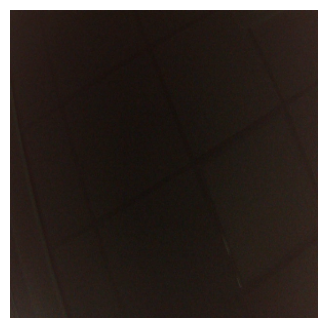

In [2]:
import cv2
import matplotlib.pyplot as plt

# 카메라 장치 번호 (일반적으로 0번이 기본 카메라)
camera_index = 0

# VideoCapture 객체 생성
cap = cv2.VideoCapture(camera_index)

# 카메라가 정상적으로 열렸는지 확인
if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
    exit()

print("카메라 구동 시작...")

# 한 프레임 읽기
ret, frame = cap.read()

# 프레임 읽기에 실패한 경우 종료
if not ret:
    print("프레임을 읽을 수 없습니다.")
    cap.release()
    exit()

# 자원 해제
cap.release()

# 이미지 크기 조정 (300x300)
resized_frame = cv2.resize(frame, (300, 300))

# BGR을 RGB로 변환 (OpenCV는 BGR 순서, Matplotlib은 RGB 순서 사용)
rgb_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB)

# 이미지를 Jupyter Notebook에 출력
plt.figure(figsize=(4, 4))  # 출력 크기 조정
plt.imshow(rgb_frame)
plt.axis('off')  # 축 제거
plt.show()


## video vision test

In [1]:
#아주 잘 작동하는 코드. 
import cv2
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# 디바이스 설정 (GPU 사용 가능 여부 확인)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 정의
class MyTransferLearningModel(torch.nn.Module):
    def __init__(self, pretrained_model, feature_extractor):
        super().__init__()
        if feature_extractor:
            for param in pretrained_model.parameters():
                param.requires_grad = False
        pretrained_model.classifier = torch.nn.Sequential(
            torch.nn.Linear(pretrained_model.classifier[1].in_features, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(64, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 2)  # 2가지 분류 (blocked, free)
        )
        self.model = pretrained_model
        
    def forward(self, data):
        logits = self.model(data)
        return logits

# 사전 학습된 MobileNetV2 모델 로드
pretrained_model = models.mobilenet_v2(pretrained=True)

# Feature Extractor 여부 설정
feature_extractor = True

# 모델 인스턴스 생성
model = MyTransferLearningModel(pretrained_model, feature_extractor).to(DEVICE)

# 저장된 가중치 파일 경로
MODEL_PATH = r"C:\Users\user\Desktop\autovehi\MobileNetV2_best_model3.pth"

# 모델 가중치 로드
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()  # 모델을 평가 모드로 설정

# 입력 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2는 224x224 입력을 기대합니다
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet 정규화
])

# 클래스 레이블 정의
class_labels = ["blocked", "free"]

# 카메라 장치 번호
camera_index = 0

# VideoCapture 객체 생성
cap = cv2.VideoCapture(camera_index)

# FPS 계산 변수 초기화
prev_time = 0

print("실시간 처리 시작... ('q' 키를 누르면 종료)")

while True:
    # 현재 시간 저장 (FPS 계산용)
    current_time = cv2.getTickCount()

    # 한 프레임 읽기
    ret, frame = cap.read()
    if not ret:
        print("프레임을 읽을 수 없습니다.")
        break

    # 모델 입력을 위한 전처리
    pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # OpenCV 이미지를 PIL 이미지로 변환
    input_tensor = transform(pil_image).unsqueeze(0).to(DEVICE)  # 배치 차원 추가 및 GPU로 이동

    # 모델 예측
    with torch.no_grad():  # 그래디언트 계산 비활성화
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)  # 가장 높은 확률의 클래스 선택

    # 예측 결과 가져오기
    result = class_labels[predicted.item()]

    # FPS 계산
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - current_time)

    # 화면 상단에 결과 표시
    cv2.putText(frame, f"Status: {result}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"FPS: {int(fps)}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # 화면에 프레임 출력
    cv2.imshow('Real-Time Classification', frame)

    # 'q' 키를 누르면 종료
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 자원 해제
cap.release()
cv2.destroyAllWindows()

실시간 처리 시작... ('q' 키를 누르면 종료)


## 점멸 방지

In [2]:
#점멸 처리
import cv2
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import time

# 디바이스 설정 (GPU 사용 가능 여부 확인)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 정의
class MyTransferLearningModel(torch.nn.Module):
    def __init__(self, pretrained_model, feature_extractor):
        super().__init__()
        if feature_extractor:
            for param in pretrained_model.parameters():
                param.requires_grad = False
        pretrained_model.classifier = torch.nn.Sequential(
            torch.nn.Linear(pretrained_model.classifier[1].in_features, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(64, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 2)  # 2가지 분류 (blocked, free)
        )
        self.model = pretrained_model
        
    def forward(self, data):
        logits = self.model(data)
        return logits

# 사전 학습된 MobileNetV2 모델 로드
pretrained_model = models.mobilenet_v2(pretrained=True)

# Feature Extractor 여부 설정
feature_extractor = True

# 모델 인스턴스 생성
model = MyTransferLearningModel(pretrained_model, feature_extractor).to(DEVICE)

# 저장된 가중치 파일 경로
MODEL_PATH = r"C:\Users\user\Desktop\autovehi\MobileNetV2_best_model3.pth"

# 모델 가중치 로드
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()  # 모델을 평가 모드로 설정

# 입력 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2는 224x224 입력을 기대합니다
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet 정규화
])

# 클래스 레이블 정의
class_labels = ["blocked", "free"]

# 카메라 장치 번호
camera_index = 0

# VideoCapture 객체 생성
cap = cv2.VideoCapture(camera_index)

# FPS 계산 변수 초기화
prev_time = 0

# 상태와 시간 초기화
last_state = None  # 이전 상태
current_state = None  # 현재 상태
state_start_time = time.time()  # 상태 시작 시간
STATE_DURATION_THRESHOLD = 0.3  # 상태가 유지되어야 하는 최소 시간 (초)

print("실시간 처리 시작... ('q' 키를 누르면 종료)")

while True:
    # 현재 시간 저장 (FPS 계산용)
    current_time = cv2.getTickCount()

    # 한 프레임 읽기
    ret, frame = cap.read()
    if not ret:
        print("프레임을 읽을 수 없습니다.")
        break

    # 모델 입력을 위한 전처리
    pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # OpenCV 이미지를 PIL 이미지로 변환
    input_tensor = transform(pil_image).unsqueeze(0).to(DEVICE)  # 배치 차원 추가 및 GPU로 이동

    # 모델 예측
    with torch.no_grad():  # 그래디언트 계산 비활성화
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)  # 가장 높은 확률의 클래스 선택

    # 예측 결과 가져오기
    result = class_labels[predicted.item()]

    # 상태 변화 체크
    if result != current_state:
        # 상태가 변경되었을 경우
        current_state = result
        state_start_time = time.time()  # 상태 시작 시간 갱신

    # 상태가 유지된 시간 계산
    elapsed_time = time.time() - state_start_time

    # 상태가 0.5초 이상 유지되었을 때만 최종 결과로 간주
    if elapsed_time >= STATE_DURATION_THRESHOLD:
        last_state = current_state

    # FPS 계산
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - current_time)

    # 화면 상단에 결과 표시
    cv2.putText(frame, f"Status: {last_state}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"FPS: {int(fps)}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # 화면에 프레임 출력
    cv2.imshow('Real-Time Classification', frame)

    # 'q' 키를 누르면 종료
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 자원 해제
cap.release()
cv2.destroyAllWindows()

실시간 처리 시작... ('q' 키를 누르면 종료)


## 전역변수 송출 테스트

In [24]:
# 점멸 처리 (카메라 실행 + 트리거 기능 추가)
import cv2
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import time

# 디바이스 설정 (GPU 사용 가능 여부 확인)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 정의
class MyTransferLearningModel(torch.nn.Module):
    def __init__(self, pretrained_model, feature_extractor):
        super().__init__()
        if feature_extractor:
            for param in pretrained_model.parameters():
                param.requires_grad = False
        pretrained_model.classifier = torch.nn.Sequential(
            torch.nn.Linear(pretrained_model.classifier[1].in_features, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(64, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 2)  # 2가지 분류 (blocked, free)
        )
        self.model = pretrained_model
        
    def forward(self, data):
        logits = self.model(data)
        return logits

# 사전 학습된 MobileNetV2 모델 로드
pretrained_model = models.mobilenet_v2(pretrained=True)

# Feature Extractor 여부 설정
feature_extractor = True

# 모델 인스턴스 생성
model = MyTransferLearningModel(pretrained_model, feature_extractor).to(DEVICE)

# 저장된 가중치 파일 경로
MODEL_PATH = r"C:\Users\user\Desktop\autovehi\MobileNetV2_best_model3.pth"

# 모델 가중치 로드
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()  # 모델을 평가 모드로 설정

# 입력 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2는 224x224 입력을 기대합니다
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet 정규화
])

# 클래스 레이블 정의
class_labels = ["blocked", "free"]

# 카메라 장치 번호
camera_index = 0

# VideoCapture 객체 생성
cap = cv2.VideoCapture(camera_index)

# FPS 계산 변수 초기화
prev_time = 0

# 상태와 시간 초기화
last_state = None  # 이전 상태
current_state = None  # 현재 상태
state_start_time = time.time()  # 상태 시작 시간
STATE_DURATION_THRESHOLD = 0.3  # 상태가 유지되어야 하는 최소 시간 (초)

# 트리거 상태 초기화
trigger_active = False  # 트리거 활성화 여부
last_trigger_time = time.time()  # 마지막 트리거 출력 시간

print("실시간 처리 시작... ('q' 키를 누르면 종료, 's' 키를 누르면 트리거 ON/OFF)")

while True:
    # 현재 시간 저장 (FPS 계산용)
    current_time = cv2.getTickCount()

    # 한 프레임 읽기
    ret, frame = cap.read()
    if not ret:
        print("프레임을 읽을 수 없습니다.")
        break

    # 모델 입력을 위한 전처리
    pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # OpenCV 이미지를 PIL 이미지로 변환
    input_tensor = transform(pil_image).unsqueeze(0).to(DEVICE)  # 배치 차원 추가 및 GPU로 이동

    # 모델 예측
    with torch.no_grad():  # 그래디언트 계산 비활성화
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)  # 가장 높은 확률의 클래스 선택

    # 예측 결과 가져오기
    result = class_labels[predicted.item()]

    # 상태 변화 체크
    if result != current_state:
        # 상태가 변경되었을 경우
        current_state = result
        state_start_time = time.time()  # 상태 시작 시간 갱신

    # 상태가 유지된 시간 계산
    elapsed_time = time.time() - state_start_time

    # 상태가 0.3초 이상 유지되었을 때만 최종 결과로 간주
    if elapsed_time >= STATE_DURATION_THRESHOLD:
        last_state = current_state

    # FPS 계산
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - current_time)

    # 화면 상단에 결과 표시
    cv2.putText(frame, f"Status: {last_state}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"FPS: {int(fps)}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # 화면에 프레임 출력
    cv2.imshow('Real-Time Classification', frame)

    # 트리거 상태에 따른 자동 출력
    if trigger_active and time.time() - last_trigger_time >= 0.5:  # 0.5초마다 두 번씩 출력
        if last_state is not None:
            numeric_state = 1 if last_state == "free" else 0  # 상태를 숫자로 변환
            print(f"현재 상태: {numeric_state} ({last_state})")
        last_trigger_time = time.time()

    # 키 입력 처리
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):  # 'q' 키를 누르면 종료
        print("프로그램 종료")
        break
    elif key == ord('s'):  # 's' 키를 누르면 트리거 ON/OFF
        trigger_active = not trigger_active  # 트리거 상태 토글
        if trigger_active:
            print("트리거 활성화됨 (1초마다 상태 출력)")
        else:
            print("트리거 비활성화됨")

# 자원 해제
cap.release()
cv2.destroyAllWindows()

실시간 처리 시작... ('q' 키를 누르면 종료, 's' 키를 누르면 트리거 ON/OFF)
트리거 활성화됨 (1초마다 상태 출력)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 1 (free)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 1 (free)
현재 상태: 1 (free)
현재 상태: 1 (free)
현재 상태: 1 (free)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 0 (blocked)
현재 상태: 1 (free)
현재 상태: 1 (free)
현재 상태: 1 (free)
현재 상태: 1 (free)
현재 상태: 1 (free)
프로그램 종료
